# Abstracción

### Ejemplo 1: Control de reproducción de audio y sintetizador

La clase `AudioPlayer` representa una abstracción de un reproductor de audio digital.


@startuml
' Ejemplo 1: AudioPlayer (control de reproducción)
class AudioPlayer {
    + volume: int
    + sample_rate: int
    + frequency: float
    + buffer_duration: float
    + play()
}
@enduml

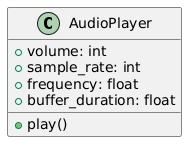

In [18]:
import numpy as np

class AudioPlayer:
    def __init__(self, volume: int, sample_rate: int, frequency: float, buffer_duration: float) -> None:
        self.volume: int = volume
        self.sample_rate: int = sample_rate
        self.frequency: float = frequency
        self.buffer_duration: float = buffer_duration

    def play(self) -> None:
        t = np.linspace(0, self.buffer_duration, int(self.sample_rate * self.buffer_duration), endpoint=False)
        audio_signal = (self.volume / 100.0) * np.sin(2 * np.pi * self.frequency * t)
        peak_val = np.max(np.abs(audio_signal))
        print(f"Reproduciendo tono de {self.frequency} Hz a {self.volume}% de volumen (Amplitud pico: {peak_val:.2f})")

    def __str__(self) -> str:
        return f"{self.frequency} Hz, Vol: {self.volume}%, SR: {self.sample_rate} Hz, Buffer: {self.buffer_duration}s"

In [19]:
player = AudioPlayer(volume=80, sample_rate=44100, frequency=440.0, buffer_duration=2.0)
print(player)
player.play()

440.0 Hz, Vol: 80%, SR: 44100 Hz, Buffer: 2.0s
Reproduciendo tono de 440.0 Hz a 80% de volumen (Amplitud pico: 0.80)


### Ejemplo 2: Gestión de reservas de estudio de grabación

El mismo ámbito del audio se abstrae de forma completamente distinta. La clase `StudioReservation` se enfoca únicamente en el aspecto administrativo y logístico de una reserva de estudio. Veamos cómo se aplica la abstracción:

1. **Atributos simplificados**: Nos centramos únicamente en las horas agendadas y en el estado de confirmación/asistencia del artista.

2. **Métodos específicos**: Incluimos operaciones de negocio clave como `confirm_booking`, `validate_schedule` y `calculate_cost`.

3. **Encapsulación y lógica de tarifas**: La validación de disponibilidad y el cálculo de tarifas según el horario están encapsulados dentro de métodos sencillos de utilizar.

@startuml
' Ejemplo 2: StudioReservation (gestión de reservas)
class StudioReservation {
    + start_hour: int
    + end_hour: int
    + is_confirmed: bool
    + confirm_booking(artist_name)
    + validate_schedule(start_hour, end_hour)
    + calculate_cost()
}
@enduml

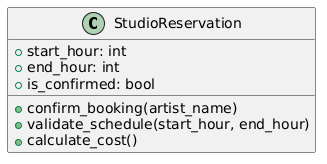

In [20]:
class StudioReservation:
    def __init__(self, start_hour: int, end_hour: int) -> None:
        self.start_hour: int = start_hour
        self.end_hour: int = end_hour
        self.is_confirmed: bool = False

    def validate_schedule(self, start_hour: int, end_hour: int) -> bool:
        # El estudio opera de 8:00 a 22:00
        return 8 <= start_hour < end_hour <= 22

    def confirm_booking(self, artist_name: str) -> None:
        if not self.validate_schedule(self.start_hour, self.end_hour):
            print(f"La reserva de {self.start_hour}:00 a {self.end_hour}:00 para {artist_name} no es válida.")
            return
        self.is_confirmed = True
        print(f"Reserva confirmada exitosamente para {artist_name} ({self.start_hour}:00 - {self.end_hour}:00).")

    def calculate_cost(self) -> float:
        hours = self.end_hour - self.start_hour
        # Tarifa plana de $50 USD por hora de estudio
        return hours * 50.0

    def __str__(self) -> str:
        status = "Confirmada" if self.is_confirmed else "Pendiente"
        return f"Sesión de {self.end_hour - self.start_hour}h ({self.start_hour}:00 - {self.end_hour}:00) - Estado: {status}"

In [21]:
reservation = StudioReservation(start_hour=14, end_hour=18)
print(reservation)
reservation.confirm_booking(artist_name="Los Hijos del Ritmo")
print(f"Costo total de la sesión: ${reservation.calculate_cost()} USD")

invalid_reservation = StudioReservation(start_hour=21, end_hour=25)
invalid_reservation.confirm_booking(artist_name="Carlos V.")

Sesión de 4h (14:00 - 18:00) - Estado: Pendiente
Reserva confirmada exitosamente para Los Hijos del Ritmo (14:00 - 18:00).
Costo total de la sesión: $200.0 USD
La reserva de 21:00 a 25:00 para Carlos V. no es válida.
